## Part 3: Rabi Oscillations and Qubit Control

The transmon's energy levels (E1-E0, and the anharmonicity between 
adjacent gaps) were derived in `part1_transmon.py`. This notebook asks 
how those levels are actually *used*: physically, a qubit is controlled 
by applying an oscillating microwave drive tuned near its natural 
frequency, producing Rabi oscillation between |0⟩ and |1⟩. This is the 
real mechanism behind every single-qubit gate on real hardware. The 
notebook then connects this control mechanism directly back to the 
transmon's anharmonicity, showing how the two together determine the 
fastest gate speed achievable without exciting unwanted transitions.

### Importing the transmon energy levels

Rather than redefining the transmon calculation here, it's imported 
directly from `solvers.py`, reusing the same E1-E0 and anharmonicity 
values derived in Part 1.

In [1]:
import sys
sys.path.append('../src')
from solvers import transmon_energy_levels
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

In [2]:
eigenvalues, eigenvectors, phi, dphi = transmon_energy_levels(E_C=1.0, E_J=50.0)
omega0 = eigenvalues[1] - eigenvalues[0]
anharmonicity = (eigenvalues[2]-eigenvalues[1]) - (eigenvalues[1]-eigenvalues[0])
print(f"omega0 = {omega0:.4f}, anharmonicity = {anharmonicity:.4f}")

omega0 = 18.9419, anharmonicity = -1.1480


### Setting up the driven qubit

H(t) = (ω₀/2)Z + Ω·cos(ωt)X describes a qubit at its natural frequency ω₀, 
driven by an oscillating field of strength Ω. This is integrated directly 
via `solve_ivp`, rather than a circuit, since it's a genuinely 
time-dependent Hamiltonian.

In [ ]:
Omega = 1.0

def schrodinger_rhs(t, psi_flat, omega_drive):
    psi = psi_flat[:2] + 1j*psi_flat[2:]
    H = 0.5*omega0*Z + Omega*np.cos(omega_drive*t)*X
    dpsi = -1j * H @ psi
    return np.concatenate([dpsi.real, dpsi.imag])

psi0 = np.array([1, 0], dtype=complex)
y0 = np.concatenate([psi0.real, psi0.imag])

### Driving on resonance

Setting the drive frequency equal to ω₀ should produce full Rabi 
oscillation, coherent, complete population transfer between |0⟩ and |1⟩.

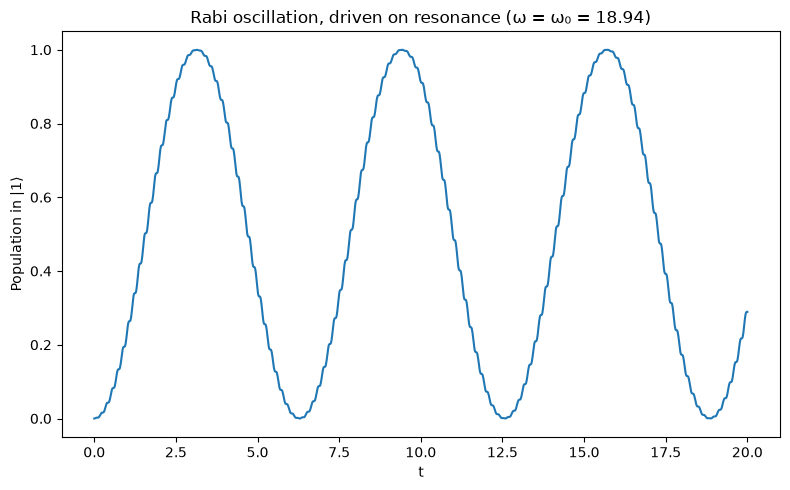

In [4]:
t_span = (0, 20)
t_eval = np.linspace(*t_span, 2000)

sol = solve_ivp(schrodinger_rhs, t_span, y0, args=(omega0,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
psi_t = sol.y[:2] + 1j*sol.y[2:]
pop1 = np.abs(psi_t[1])**2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_eval, pop1)
ax.set_xlabel('t')
ax.set_ylabel('Population in |1⟩')
ax.set_title(f'Rabi oscillation, driven on resonance (ω = ω₀ = {omega0:.2f})')
plt.tight_layout()
plt.savefig('../figures/rabi_resonant.png', dpi=120)

Population reaches essentially 1.0, confirming a complete flip to |1⟩. 
The fast oscillations riding on the slower envelope are real, not 
numerical error, they come from counter-rotating terms in the lab-frame 
drive that don't perfectly track the qubit's own rotation. In practice, 
both theory and experiment apply the rotating wave approximation (RWA) 
to average these out, leaving clean Rabi flopping; the underlying 
envelope shown here is that same physical oscillation.

### Resonance curve

Sweeping the drive frequency and recording the maximum population 
transferred at each shows how sharply the qubit responds only near ω₀, 
the basis for frequency-selective control.

In [5]:
def max_population_at_drive(omega_drive, t_max=20):
    sol = solve_ivp(schrodinger_rhs, (0, t_max), y0, args=(omega_drive,),
                     t_eval=np.linspace(0, t_max, 500), rtol=1e-9, atol=1e-9)
    psi_t = sol.y[:2] + 1j*sol.y[2:]
    return np.max(np.abs(psi_t[1])**2)

drive_freqs = np.linspace(omega0 - 3, omega0 + 3, 60)
max_pops = [max_population_at_drive(w) for w in drive_freqs]

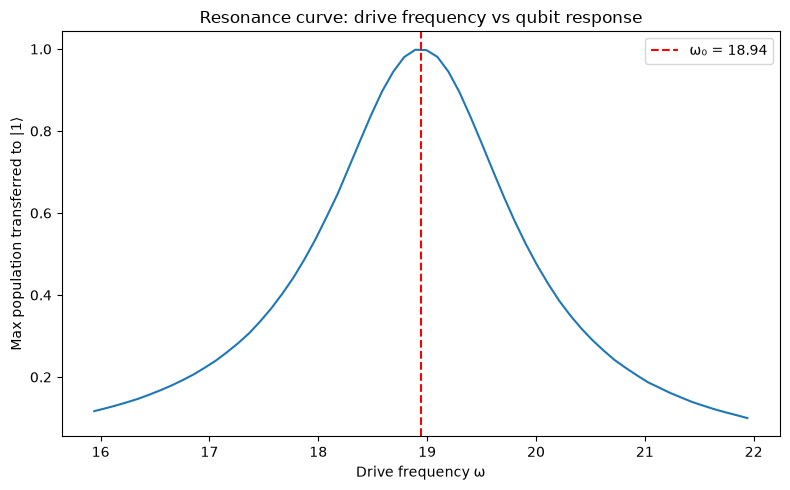

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(drive_freqs, max_pops)
ax.axvline(omega0, color='red', linestyle='--', label=f'ω₀ = {omega0:.2f}')
ax.set_xlabel('Drive frequency ω')
ax.set_ylabel('Max population transferred to |1⟩')
ax.set_title('Resonance curve: drive frequency vs qubit response')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/rabi_resonance_curve.png', dpi=120)

The response peaks sharply at ω₀ and falls off away from it, as expected 
for a driven resonance.


### Comparing resonance width to anharmonicity

The resonance curve's width can be compared directly to the transmon's 
anharmonicity (the frequency gap between the 0→1 and 1→2 transitions). 
If the anharmonicity exceeds the resonance width, driving at ω₀ genuinely 
avoids exciting the unwanted 1→2 transition; if not, some leakage is 
expected.

In [7]:
max_pops_arr = np.array(max_pops)
half_max = max_pops_arr.max() / 2
above_half = drive_freqs[max_pops_arr >= half_max]
resonance_width = above_half.max() - above_half.min()

print(f"Resonance curve width (approx FWHM): {resonance_width:.3f}")
print(f"Transmon anharmonicity: {abs(anharmonicity):.3f}")
print(f"Ratio (anharmonicity / resonance width): {abs(anharmonicity)/resonance_width:.2f}")

Resonance curve width (approx FWHM): 1.932
Transmon anharmonicity: 1.148
Ratio (anharmonicity / resonance width): 0.59


At Ω=1.0, the ratio is 0.59, less than 1, meaning the resonance curve is 
actually *wider* than the anharmonicity gap. Addressing 0→1 at this drive 
strength would risk exciting 1→2 as well. This reflects a real design 
constraint: real hardware must choose a drive strength small enough that 
the resonance width stays below the anharmonicity, at the cost of slower 
gates, a genuine speed-vs-selectivity tradeoff.

### Finding the optimal drive strength

Since weaker drives narrow the resonance (better selectivity) but slow 
the gate down, and stronger drives do the opposite, there's a well-defined 
optimum: the fastest drive strength that still keeps the resonance width 
at or below the anharmonicity, avoiding leakage. This crossover point is 
found by sweeping Ω and locating where the ratio equals 1.

Optimal drive strength (fastest safe gate): Ω* = 0.719
Corresponding gate time (~π/Ω*): 4.372


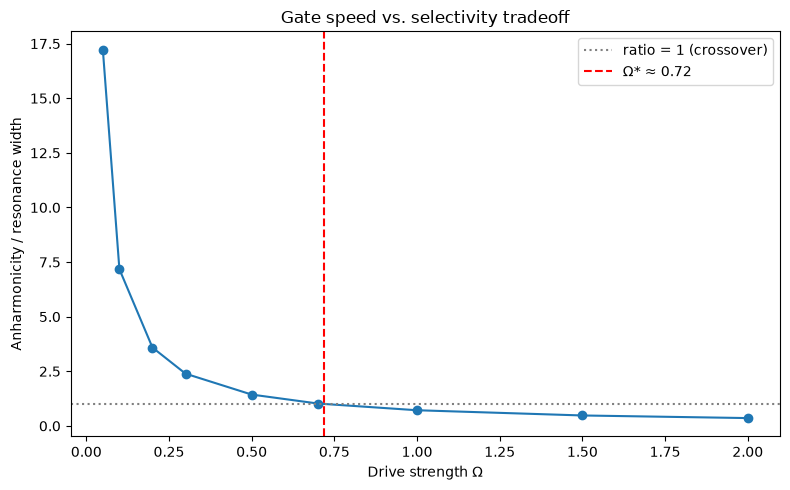

In [8]:
def get_resonance_width(Omega_val):
    def rhs(t, psi_flat, omega_drive):
        psi = psi_flat[:2] + 1j*psi_flat[2:]
        H = 0.5*omega0*Z + Omega_val*np.cos(omega_drive*t)*X
        dpsi = -1j*H@psi
        return np.concatenate([dpsi.real, dpsi.imag])
    def max_pop(omega_drive, t_max):
        sol = solve_ivp(rhs, (0, t_max), y0, args=(omega_drive,),
                         t_eval=np.linspace(0, t_max, 150), rtol=1e-6, atol=1e-6)
        psi_t = sol.y[:2] + 1j*sol.y[2:]
        return np.max(np.abs(psi_t[1])**2)
    span = max(6*Omega_val, 0.5)
    t_max = min(max(12, 6*np.pi/Omega_val), 60)
    freqs = np.linspace(omega0-span, omega0+span, 31)
    pops = np.array([max_pop(w, t_max) for w in freqs])
    half = pops.max()/2
    above = freqs[pops >= half]
    return above.max() - above.min()

Omega_values = np.array([0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0])
widths = np.array([get_resonance_width(om) for om in Omega_values])
ratios = abs(anharmonicity) / widths

from scipy.optimize import brentq
def f(Omega_val):
    return abs(anharmonicity) / get_resonance_width(Omega_val) - 1

Omega_star = brentq(f, 0.4, 0.9, xtol=0.01)
gate_time_star = np.pi / Omega_star

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Omega_values, ratios, 'o-')
ax.axhline(1, color='gray', linestyle=':', label='ratio = 1 (crossover)')
ax.axvline(Omega_star, color='red', linestyle='--', label=f'Ω* ≈ {Omega_star:.2f}')
ax.set_xlabel('Drive strength Ω')
ax.set_ylabel('Anharmonicity / resonance width')
ax.set_title('Gate speed vs. selectivity tradeoff')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/rabi_tradeoff.png', dpi=120)

print(f"Optimal drive strength (fastest safe gate): Ω* = {Omega_star:.3f}")
print(f"Corresponding gate time (~π/Ω*): {gate_time_star:.3f}")

### Result

The crossover occurs at Ω* ≈ 0.72, giving a gate time of π/Ω* ≈ 4.37. 
This is the theoretical speed limit for a clean, selective single-qubit 
gate on this transmon design: faster drives risk exciting the 1→2 
transition, slower drives are safely selective but waste gate time. This 
number, along with the anharmonicity it depends on, will be compared 
against the qubit's coherence time in the decoherence notebook, giving a 
complete, self-consistent picture of how many gate operations this qubit 
design could perform before decohering.